In [ ]:
   from google.colab import drive
   drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
   import os, torch

   base = '/content/drive/MyDrive/robustness-checker'
   for d in ['data', 'models', 'src', 'results']:
       os.makedirs(f'{base}/{d}', exist_ok=True)

   print("Folders:", os.listdir(base))
   print("CUDA available:", torch.cuda.is_available())
   print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

Folders: ['data', 'models', 'src', 'results']
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"itaqiz","key":"KGAT_9a868e0ebc7f9f1f6957824e6b68648c"}\n'}

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhriddinmuxiddinov/fruits-and-vegetables-dataset")

print("Path to dataset files:", path)

100%|██████████| 870M/870M [00:53<00:00, 16.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhriddinmuxiddinov/fruits-and-vegetables-dataset/versions/2


In [ ]:
import os, shutil

root = '/root/.cache/kagglehub/datasets/muhriddinmuxiddinov/fruits-and-vegetables-dataset/versions/2'

fruits_dir = None
for dirpath, dirnames, filenames in os.walk(root):
    if os.path.basename(dirpath) == 'Fruits':
        fruits_dir = dirpath
        break
print("Found:", fruits_dir)

shutil.make_archive('/content/drive/MyDrive/robustness-checker/data/fruits', 'zip', fruits_dir)
print("Saved zip to Drive")

Found: /root/.cache/kagglehub/datasets/muhriddinmuxiddinov/fruits-and-vegetables-dataset/versions/2/Fruits_Vegetables_Dataset(12000)/Fruits
Saved zip to Drive


In [ ]:
total = 0
for cls in sorted(os.listdir(fruits_dir)):
    cls_path = os.path.join(fruits_dir, cls)
    if os.path.isdir(cls_path):
        n = len(os.listdir(cls_path))
        total += n
        print(f"{n:5d}  {cls}")

print("Total images:", total)

  612  FreshApple
  624  FreshBanana
  605  FreshMango
  609  FreshOrange
  603  FreshStrawberry
  588  RottenApple
  576  RottenBanana
  593  RottenMango
  591  RottenOrange
  596  RottenStrawberry
Total images: 5997


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

rows = []
for cls in sorted(os.listdir(fruits_dir)):
    cls_path = os.path.join(fruits_dir, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            rows.append({
                'path': os.path.join(cls, fname),
                'label': 0 if cls.startswith('Fresh') else 1,
                'fruit': cls.replace('Fresh', '').replace('Rotten', ''),
                'cls': cls,
            })

df = pd.DataFrame(rows)
print("Images found:", len(df))

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['cls'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['cls'], random_state=42)

df['split'] = 'train'
df.loc[df.index.isin(val_df.index), 'split'] = 'val'
df.loc[df.index.isin(test_df.index), 'split'] = 'test'

df.to_csv('/content/drive/MyDrive/robustness-checker/data/split.csv', index=False)

print(df['split'].value_counts())
print(df.groupby('split')['label'].mean().round(3))

Images found: 5988
split
train    4191
test      899
val       898
Name: count, dtype: int64
split
test     0.488
train    0.490
val      0.492
Name: label, dtype: float64


In [ ]:
skipped = []
for cls in sorted(os.listdir(fruits_dir)):
    cls_path = os.path.join(fruits_dir, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            skipped.append(os.path.join(cls, fname))

print(len(skipped))
print(skipped)

9
['FreshBanana/freshBanana (1).webp', 'RottenApple/rottenApple (5).webp', 'RottenApple/rottenApple (1).webp', 'RottenApple/rottenApple (2).webp', 'RottenApple/rottenApple (4).webp', 'RottenApple/rottenApple (3).webp', 'RottenBanana/rottenBanana (2).webp', 'RottenBanana/rottenBanana (3).webp', 'RottenBanana/rottenBanana (1).webp']


In [ ]:
rows = []
for cls in sorted(os.listdir(fruits_dir)):
    cls_path = os.path.join(fruits_dir, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
            rows.append({
                'path': os.path.join(cls, fname),
                'label': 0 if cls.startswith('Fresh') else 1,
                'fruit': cls.replace('Fresh', '').replace('Rotten', ''),
                'cls': cls,
            })

df = pd.DataFrame(rows)
print("Images found:", len(df))

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['cls'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['cls'], random_state=42)

df['split'] = 'train'
df.loc[df.index.isin(val_df.index), 'split'] = 'val'
df.loc[df.index.isin(test_df.index), 'split'] = 'test'

df.to_csv('/content/drive/MyDrive/robustness-checker/data/split.csv', index=False)

print(df['split'].value_counts())
print(df.groupby('split')['label'].mean().round(3))

Images found: 5997
split
train    4197
test      900
val       900
Name: count, dtype: int64
split
test     0.491
train    0.491
val      0.490
Name: label, dtype: float64


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

In [ ]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class FruitDataset(Dataset):
    def __init__(self, table, root, transform):
        self.table = table.reset_index(drop=True)
        self.root = root
        self.transform = transform

    def __len__(self):
        return len(self.table)

    def __getitem__(self, i):
        row = self.table.iloc[i]
        img = Image.open(os.path.join(self.root, row['path'])).convert('RGB')
        return self.transform(img), int(row['label'])

train_ds = FruitDataset(df[df['split'] == 'train'], fruits_dir, train_tf)
val_ds = FruitDataset(df[df['split'] == 'val'], fruits_dir, eval_tf)
test_ds = FruitDataset(df[df['split'] == 'test'], fruits_dir, eval_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(len(train_ds), len(val_ds), len(test_ds))

4197 900 900


In [ ]:
bad = []
for p in df['path']:
    try:
        Image.open(os.path.join(fruits_dir, p)).convert('RGB')
    except Exception as e:
        bad.append((p, str(e)))
print("Unreadable images:", len(bad), bad[:5])

images, labels = next(iter(train_loader))
print(images.shape, labels[:10])

Unreadable images: 0 []
torch.Size([32, 3, 224, 224]) tensor([0, 0, 0, 1, 0, 1, 1, 0, 1, 1])


In [ ]:
import torch.nn as nn
from torchvision import models

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

images, labels = next(iter(train_loader))
with torch.no_grad():
    out = model(images.to(device))
print(out.shape)
print(round(sum(p.numel() for p in model.parameters()) / 1e6, 2), "million parameters")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


torch.Size([32, 2])
11.18 million parameters


In [ ]:
base = '/content/drive/MyDrive/robustness-checker'
ckpt_path = f'{base}/models/resnet18_last.pt'
best_path = f'{base}/models/resnet18_best.pt'

def evaluate(loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return loss_sum / total, correct / total

In [ ]:
EPOCHS = 5
start_epoch, best_val = 0, 0.0

if os.path.exists(ckpt_path):
    ck = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ck['model'])
    optimizer.load_state_dict(ck['optimizer'])
    start_epoch, best_val = ck['epoch'] + 1, ck['best_val']
    print(f"Resuming from epoch {start_epoch}")

for epoch in range(start_epoch, EPOCHS):
    model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)

    train_loss = running / len(train_ds)
    val_loss, val_acc = evaluate(val_loader)
    print(f"Epoch {epoch + 1}/{EPOCHS}  train_loss {train_loss:.4f}  val_loss {val_loss:.4f}  val_acc {val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), best_path)

    torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
                'epoch': epoch, 'best_val': best_val}, ckpt_path)

Epoch 1/5  train_loss 0.0891  val_loss 0.0291  val_acc 0.9911
Epoch 2/5  train_loss 0.0247  val_loss 0.0282  val_acc 0.9867
Epoch 3/5  train_loss 0.0264  val_loss 0.0259  val_acc 0.9933
Epoch 4/5  train_loss 0.0144  val_loss 0.0228  val_acc 0.9944
Epoch 5/5  train_loss 0.0161  val_loss 0.0171  val_acc 0.9933


In [ ]:
model.load_state_dict(torch.load(best_path, map_location=device))
test_loss, test_acc = evaluate(test_loader)
print(f"Test accuracy: {test_acc:.4f}  Test loss: {test_loss:.4f}")

def predict(loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for x, _ in loader:
            probs.append(torch.softmax(model(x.to(device)), dim=1).cpu())
    return torch.cat(probs)

test_probs = predict(test_loader)
test_tbl = df[df['split'] == 'test'].reset_index(drop=True)
test_tbl['pred'] = test_probs.argmax(1).numpy()
test_tbl['conf'] = test_probs.max(1).values.numpy()
test_tbl['correct'] = test_tbl['pred'] == test_tbl['label']

print(test_tbl.groupby('fruit')['correct'].mean().round(3))
print("Errors:", (~test_tbl['correct']).sum(), "of", len(test_tbl))
print("Mean confidence when correct:", round(test_tbl.loc[test_tbl['correct'], 'conf'].mean(), 3))
print("Mean confidence when wrong:  ", round(test_tbl.loc[~test_tbl['correct'], 'conf'].mean(), 3))

Test accuracy: 0.9944  Test loss: 0.0187
fruit
Apple         0.994
Banana        0.989
Mango         1.000
Orange        1.000
Strawberry    0.989
Name: correct, dtype: float64
Errors: 5 of 900
Mean confidence when correct: 0.996
Mean confidence when wrong:   0.822


In [ ]:
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import ImageFilter, ImageEnhance

In [ ]:
SEVERITIES = {
    'blur':      [1, 2, 3, 4, 6],
    'low_light': [0.6, 0.45, 0.3, 0.2, 0.1],
    'noise':     [10, 20, 35, 50, 70],
    'jpeg':      [50, 30, 15, 8, 4],
    'occlusion': [0.05, 0.10, 0.20, 0.30, 0.40],
}

def corrupt(img, kind, level, seed=0):
    if level == 0:
        return img
    p = SEVERITIES[kind][level - 1]

    if kind == 'blur':
        return img.filter(ImageFilter.GaussianBlur(p))

    if kind == 'low_light':
        return ImageEnhance.Brightness(img).enhance(p)

    if kind == 'noise':
        rng = np.random.default_rng(seed)
        arr = np.asarray(img).astype(np.float32)
        arr = arr + rng.normal(0, p, arr.shape)
        return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

    if kind == 'jpeg':
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=p)
        buf.seek(0)
        return Image.open(buf).convert('RGB')

    if kind == 'occlusion':
        w, h = img.size
        side = int((p * w * h) ** 0.5)
        rng = np.random.default_rng(seed)
        x0 = int(rng.integers(0, w - side + 1))
        y0 = int(rng.integers(0, h - side + 1))
        out = img.copy()
        out.paste((0, 0, 0), (x0, y0, x0 + side, y0 + side))
        return out

    raise ValueError(kind)

In [ ]:
base_tf = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
final_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])

class CorruptedDataset(Dataset):
    def __init__(self, table, root, kind, level):
        self.table = table.reset_index(drop=True)
        self.root, self.kind, self.level = root, kind, level

    def __len__(self):
        return len(self.table)

    def __getitem__(self, i):
        row = self.table.iloc[i]
        img = base_tf(Image.open(os.path.join(self.root, row['path'])).convert('RGB'))
        img = corrupt(img, self.kind, self.level, seed=i)
        return final_tf(img), int(row['label'])

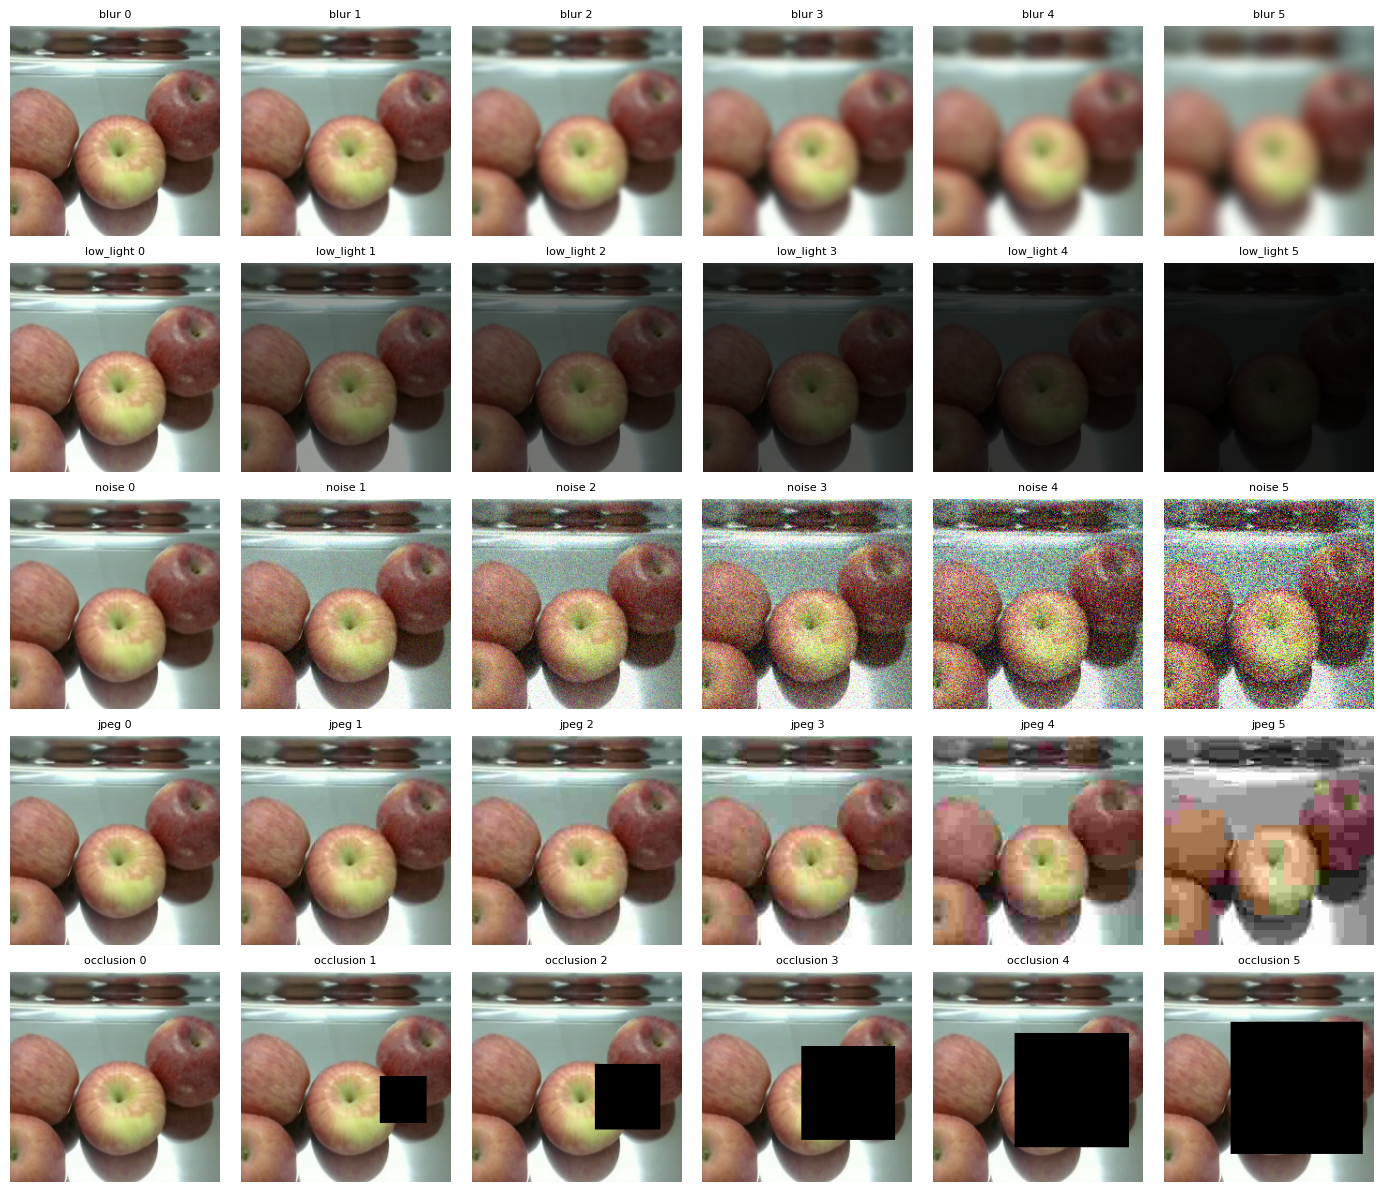

In [ ]:
sample = base_tf(Image.open(os.path.join(fruits_dir, test_tbl.loc[0, 'path'])).convert('RGB'))
kinds = list(SEVERITIES)

fig, axes = plt.subplots(len(kinds), 6, figsize=(14, 12))
for r, kind in enumerate(kinds):
    for c in range(6):
        axes[r, c].imshow(corrupt(sample, kind, c, seed=0))
        axes[r, c].axis('off')
        axes[r, c].set_title(f"{kind} {c}", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
SEVERITIES = {
    'blur':      [1, 2, 3, 4, 6],
    'low_light': [0.7, 0.5, 0.35, 0.25, 0.15],
    'noise':     [8, 16, 28, 40, 55],
    'jpeg':      [60, 40, 25, 15, 10],
    'occlusion': [0.05, 0.10, 0.20, 0.30, 0.40],
}

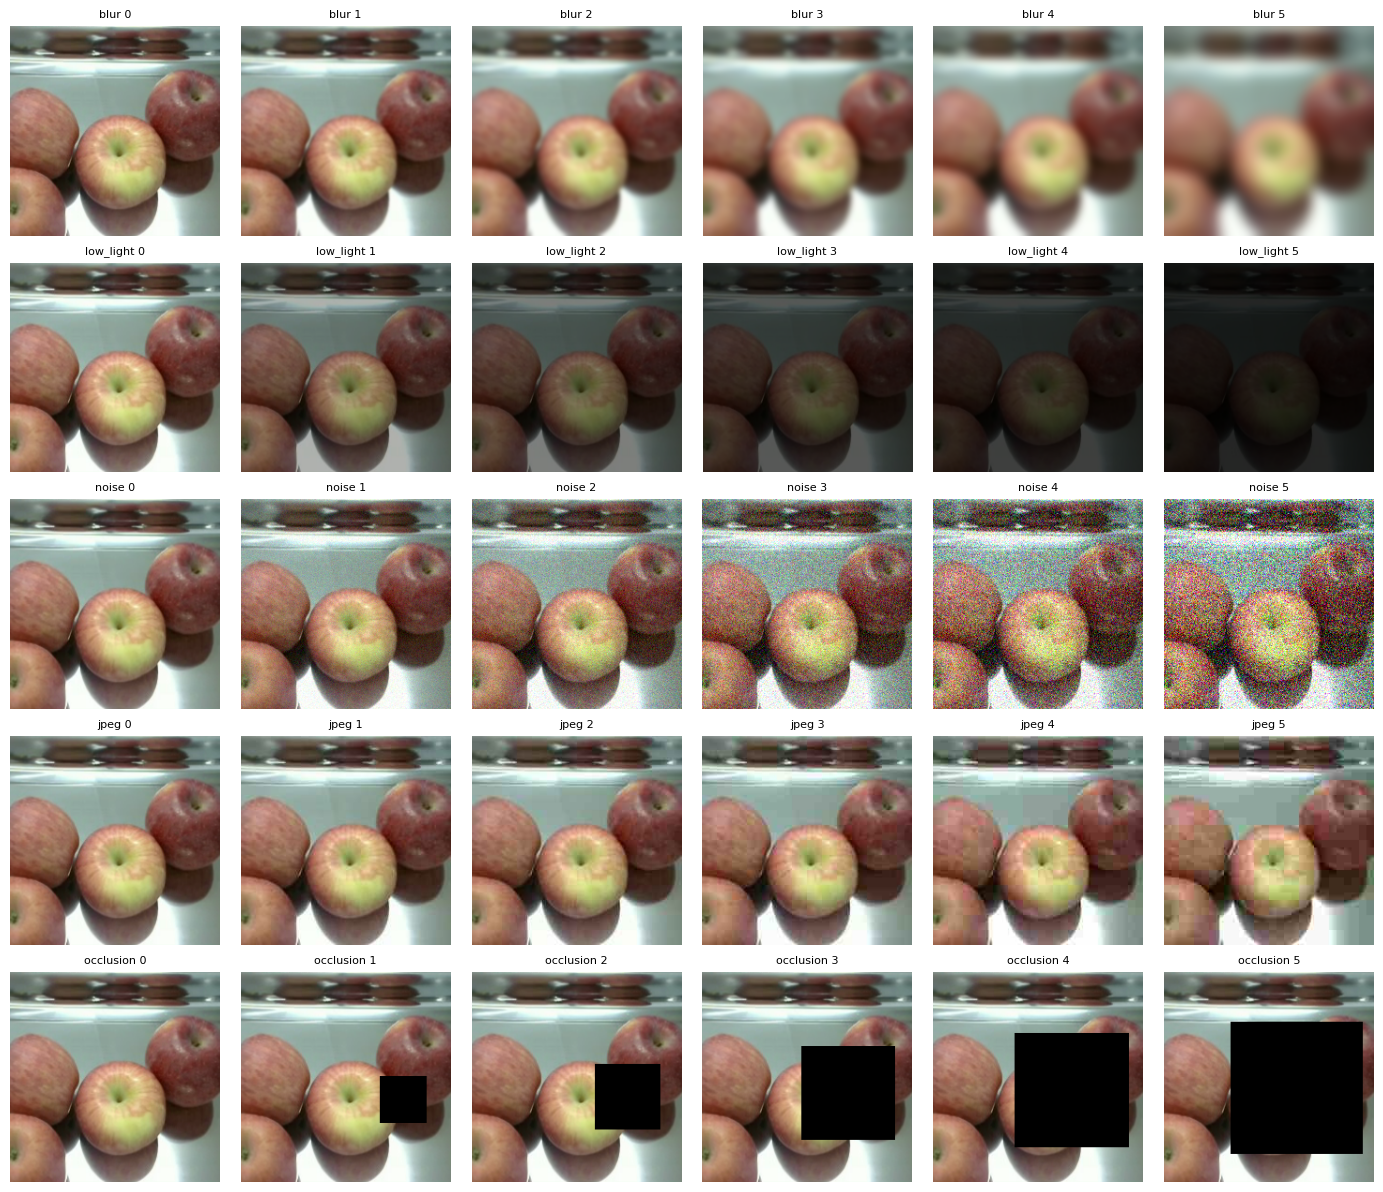

In [ ]:
sample = base_tf(Image.open(os.path.join(fruits_dir, test_tbl.loc[0, 'path'])).convert('RGB'))
kinds = list(SEVERITIES)

fig, axes = plt.subplots(len(kinds), 6, figsize=(14, 12))
for r, kind in enumerate(kinds):
    for c in range(6):
        axes[r, c].imshow(corrupt(sample, kind, c, seed=0))
        axes[r, c].axis('off')
        axes[r, c].set_title(f"{kind} {c}", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
def make_rows(probs, kind, level):
    part = test_tbl[['path', 'label', 'fruit']].copy()
    part['kind'] = kind
    part['level'] = level
    part['pred'] = probs.argmax(1).numpy()
    part['conf'] = probs.max(1).values.numpy()
    part['p_rotten'] = probs[:, 1].numpy()
    return part

results = []
for kind in SEVERITIES:
    results.append(make_rows(test_probs, kind, 0))
    for level in range(1, 6):
        ds = CorruptedDataset(test_tbl, fruits_dir, kind, level)
        loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2)
        part = make_rows(predict(loader), kind, level)
        results.append(part)
        print(f"{kind:10s} level {level}  acc {(part['pred'] == part['label']).mean():.4f}")

res = pd.concat(results, ignore_index=True)
res.to_csv(f'{base}/results/corruption_results.csv', index=False)
print(res.shape)

blur       level 1  acc 0.9944
blur       level 2  acc 0.9656
blur       level 3  acc 0.8756
blur       level 4  acc 0.7744
blur       level 5  acc 0.6367
low_light  level 1  acc 0.9944
low_light  level 2  acc 0.9911
low_light  level 3  acc 0.9644
low_light  level 4  acc 0.8656
low_light  level 5  acc 0.6067
noise      level 1  acc 0.9933
noise      level 2  acc 0.9111
noise      level 3  acc 0.7278
noise      level 4  acc 0.6800
noise      level 5  acc 0.6711
jpeg       level 1  acc 0.9922
jpeg       level 2  acc 0.9900
jpeg       level 3  acc 0.9789
jpeg       level 4  acc 0.9322
jpeg       level 5  acc 0.8978
occlusion  level 1  acc 0.9911
occlusion  level 2  acc 0.9889
occlusion  level 3  acc 0.9611
occlusion  level 4  acc 0.9389
occlusion  level 5  acc 0.8856
(27000, 8)


kind    blur   jpeg  low_light  noise  occlusion
level                                           
0      0.994  0.994      0.994  0.994      0.994
1      0.994  0.992      0.994  0.993      0.991
2      0.966  0.990      0.991  0.911      0.989
3      0.876  0.979      0.964  0.728      0.961
4      0.774  0.932      0.866  0.680      0.939
5      0.637  0.898      0.607  0.671      0.886


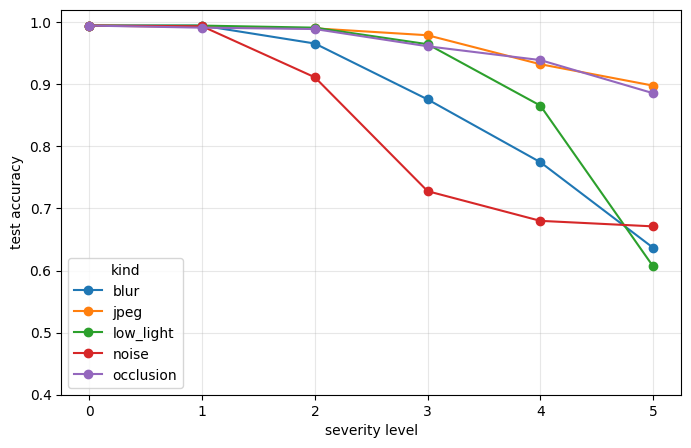

In [ ]:
acc = (res.assign(correct=res['pred'] == res['label'])
          .groupby(['kind', 'level'])['correct'].mean()
          .unstack(0))
print(acc.round(3))

acc.plot(marker='o', figsize=(8, 5))
plt.xlabel('severity level')
plt.ylabel('test accuracy')
plt.ylim(0.4, 1.02)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
res['correct'] = res['pred'] == res['label']
res['sure_wrong'] = (~res['correct']) & (res['conf'] >= 0.9)

rotten_rate = res.groupby(['kind', 'level'])['pred'].mean().unstack(0)
print("Share predicted rotten (true share is 0.491):")
print(rotten_rate.round(3))

wrong_conf = res[~res['correct']].groupby(['kind', 'level'])['conf'].mean().unstack(0)
print("\nMean confidence on WRONG predictions:")
print(wrong_conf.round(3))

sure_wrong = res.groupby(['kind', 'level'])['sure_wrong'].mean().unstack(0)
print("\nShare of all images that are wrong AND at least 90% confident:")
print(sure_wrong.round(3))

Share predicted rotten (true share is 0.491):
kind    blur   jpeg  low_light  noise  occlusion
level                                           
0      0.494  0.494      0.494  0.494      0.494
1      0.494  0.497      0.490  0.491      0.498
2      0.463  0.497      0.489  0.571      0.498
3      0.402  0.508      0.504  0.734      0.494
4      0.326  0.546      0.594  0.740      0.483
5      0.190  0.536      0.869  0.676      0.459

Mean confidence on WRONG predictions:
kind    blur   jpeg  low_light  noise  occlusion
level                                           
0      0.822  0.822      0.822  0.822      0.822
1      0.701  0.875      0.843  0.735      0.732
2      0.756  0.771      0.875  0.772      0.718
3      0.807  0.767      0.782  0.801      0.667
4      0.827  0.751      0.770  0.766      0.669
5      0.801  0.762      0.769  0.667      0.622

Share of all images that are wrong AND at least 90% confident:
kind    blur   jpeg  low_light  noise  occlusion
level             

In [ ]:
thresholds = [0.6, 0.7, 0.8, 0.9, 0.95, 0.99]

rows = []
for t in thresholds:
    res['flag'] = res['conf'] < t
    for (kind, level), g in res.groupby(['kind', 'level']):
        kept = g[~g['flag']]
        n_wrong = (~g['correct']).sum()
        rows.append({
            'threshold': t, 'kind': kind, 'level': level,
            'review_rate': g['flag'].mean(),
            'auto_acc': kept['correct'].mean() if len(kept) else np.nan,
            'errors_caught': (g['flag'] & ~g['correct']).sum() / n_wrong if n_wrong else np.nan,
        })
thr = pd.DataFrame(rows)

hard = thr[thr['level'] >= 3].groupby(['threshold', 'kind'])[['review_rate', 'auto_acc', 'errors_caught']].mean()
for m in ['review_rate', 'auto_acc', 'errors_caught']:
    print(m)
    print(hard[m].unstack('kind').round(3))
    print()

clean = thr[(thr['level'] == 0) & (thr['kind'] == 'blur')].set_index('threshold')
print("Clean images:")
print(clean[['review_rate', 'auto_acc', 'errors_caught']].round(3))

review_rate
kind        blur   jpeg  low_light  noise  occlusion
threshold                                           
0.60       0.060  0.033      0.053  0.163      0.086
0.70       0.124  0.060      0.109  0.307      0.161
0.80       0.201  0.104      0.186  0.461      0.229
0.90       0.313  0.170      0.298  0.619      0.313
0.95       0.406  0.242      0.396  0.724      0.392
0.99       0.581  0.404      0.561  0.861      0.563

auto_acc
kind        blur   jpeg  low_light  noise  occlusion
threshold                                           
0.60       0.780  0.949      0.827  0.726      0.958
0.70       0.796  0.957      0.849  0.753      0.976
0.80       0.817  0.969      0.881  0.779      0.985
0.90       0.853  0.975      0.923  0.830      0.992
0.95       0.885  0.984      0.958  0.879      0.997
0.99       0.940  0.996      0.990  0.975      0.999

errors_caught
kind        blur   jpeg  low_light  noise  occlusion
threshold                                           
0.60     

In [ ]:
val_tbl = df[df['split'] == 'val'].reset_index(drop=True)

def run_corruptions(table):
    out = []
    for kind in SEVERITIES:
        for level in range(0, 6):
            ds = CorruptedDataset(table, fruits_dir, kind, level)
            loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2)
            probs = predict(loader)
            part = table[['path', 'label', 'fruit']].copy()
            part['kind'] = kind
            part['level'] = level
            part['pred'] = probs.argmax(1).numpy()
            part['conf'] = probs.max(1).values.numpy()
            part['p_rotten'] = probs[:, 1].numpy()
            out.append(part)
    return pd.concat(out, ignore_index=True)

val_res = run_corruptions(val_tbl)
val_res['correct'] = val_res['pred'] == val_res['label']
val_res.to_csv(f'{base}/results/corruption_results_val.csv', index=False)
print(val_res.shape)

(27000, 9)


In [ ]:
def threshold_summary(r, thresholds=(0.6, 0.7, 0.8, 0.9, 0.95, 0.99)):
    rows = []
    for t in thresholds:
        tmp = r.assign(flag=r['conf'] < t)
        for (kind, level), g in tmp.groupby(['kind', 'level']):
            kept = g[~g['flag']]
            n_wrong = (~g['correct']).sum()
            rows.append({
                'threshold': t, 'kind': kind, 'level': level,
                'review_rate': g['flag'].mean(),
                'auto_acc': kept['correct'].mean() if len(kept) else np.nan,
                'errors_caught': (g['flag'] & ~g['correct']).sum() / n_wrong if n_wrong else np.nan,
            })
    return pd.DataFrame(rows)

def compact(thr):
    hard = thr[thr['level'] >= 3].groupby('threshold')[['review_rate', 'auto_acc', 'errors_caught']].mean()
    hard['clean_review_rate'] = thr[thr['level'] == 0].groupby('threshold')['review_rate'].mean()
    return hard.round(3)

print("VALIDATION")
print(compact(threshold_summary(val_res)))

VALIDATION
           review_rate  auto_acc  errors_caught  clean_review_rate
threshold                                                         
0.60             0.077     0.846          0.223              0.003
0.70             0.150     0.865          0.416              0.008
0.80             0.234     0.887          0.584              0.010
0.90             0.343     0.913          0.740              0.018
0.95             0.429     0.939          0.831              0.022
0.99             0.588     0.979          0.953              0.047


In [ ]:
import json

with open(f'{base}/results/config.json', 'w') as f:
    json.dump({'threshold': THRESHOLD}, f)

with open(f'{base}/results/config.json') as f:
    print(json.load(f))

{'threshold': 0.95}


In [ ]:
PROBES = [('blur', 2), ('low_light', 2), ('noise', 2), ('jpeg', 2), ('occlusion', 2)]
FIELD_LEVELS = [3, 5]

class FlipDataset(Dataset):
    def __init__(self, table, root, kind, level):
        self.table = table.reset_index(drop=True)
        self.root, self.kind, self.level = root, kind, level

    def __len__(self):
        return len(self.table)

    def __getitem__(self, i):
        row = self.table.iloc[i]
        img = base_tf(Image.open(os.path.join(self.root, row['path'])).convert('RGB'))
        field = corrupt(img, self.kind, self.level, seed=i)
        views = [field] + [corrupt(field, k, l, seed=i + 10000) for k, l in PROBES]
        return torch.stack([final_tf(v) for v in views]), int(row['label'])

def run_flip(table):
    out = []
    conditions = [('clean', 0)] + [(k, l) for k in SEVERITIES for l in FIELD_LEVELS]
    for kind, level in conditions:
        loader = DataLoader(FlipDataset(table, fruits_dir, kind, level),
                            batch_size=16, shuffle=False, num_workers=2)
        model.eval()
        P = []
        with torch.no_grad():
            for x, _ in loader:
                b, v = x.shape[:2]
                p = torch.softmax(model(x.reshape(b * v, *x.shape[2:]).to(device)), dim=1)
                P.append(p.reshape(b, v, 2).cpu())
        P = torch.cat(P)

        field_pred = P[:, 0].argmax(1)
        flips = P[:, 1:].argmax(2) != field_pred[:, None]

        part = table[['path', 'label', 'fruit']].copy().reset_index(drop=True)
        part['kind'], part['level'] = kind, level
        part['pred'] = field_pred.numpy()
        part['conf'] = P[:, 0].max(1).values.numpy()
        part['n_flips'] = flips.sum(1).numpy()
        out.append(part)
        print(f"done: {kind} level {level}")
    return pd.concat(out, ignore_index=True)

val_flip = run_flip(val_tbl)
val_flip['correct'] = val_flip['pred'] == val_flip['label']
val_flip.to_csv(f'{base}/results/flip_results_val.csv', index=False)
print(val_flip.shape)

done: clean level 0
done: blur level 3
done: blur level 5
done: low_light level 3
done: low_light level 5
done: noise level 3
done: noise level 5
done: jpeg level 3
done: jpeg level 5
done: occlusion level 3
done: occlusion level 5
(9900, 9)


In [ ]:
def flip_summary(r, t=THRESHOLD):
    r = r.assign(by_conf=r['conf'] < t, by_flip=r['n_flips'] > 0)
    r['either'] = r['by_conf'] | r['by_flip']
    r['group'] = np.where(r['level'] == 0, 'clean', 'degraded')
    rows = []
    for grp, g in r.groupby('group'):
        wrong = ~g['correct']
        for rule in ['by_conf', 'by_flip', 'either']:
            kept = g[~g[rule]]
            rows.append({
                'group': grp, 'rule': rule,
                'review_rate': g[rule].mean(),
                'auto_acc': kept['correct'].mean(),
                'errors_caught': (g[rule] & wrong).sum() / max(wrong.sum(), 1),
            })
    return pd.DataFrame(rows).round(3)

print(flip_summary(val_flip))

conf_wrong = val_flip[(~val_flip['correct']) & (val_flip['conf'] >= THRESHOLD) & (val_flip['level'] > 0)]
print("\nConfident errors on degraded images:", len(conf_wrong))
print(conf_wrong.assign(caught=conf_wrong['n_flips'] > 0).groupby('kind')['caught'].agg(['mean', 'size']).round(3))

      group     rule  review_rate  auto_acc  errors_caught
0     clean  by_conf        0.022     0.998          0.600
1     clean  by_flip        0.128     0.997          0.600
2     clean   either        0.139     0.997          0.600
3  degraded  by_conf        0.439     0.956          0.862
4  degraded  by_flip        0.409     0.925          0.753
5  degraded   either        0.561     0.978          0.946

Confident errors on degraded images: 223
            mean  size
kind                  
blur       0.360    86
jpeg       0.480    25
low_light  0.846    39
noise      0.851    67
occlusion  0.333     6


In [ ]:
group = pd.Series(np.where(val_flip['level'] == 0, 'clean', 'degraded'), index=val_flip.index)
by_conf = val_flip['conf'] < THRESHOLD

rows = []
for k in [None, 1, 2, 3]:
    by_flip = (val_flip['n_flips'] >= k) if k else pd.Series(False, index=val_flip.index)
    flag = by_conf | by_flip
    for grp in ['clean', 'degraded']:
        m = group == grp
        wrong = ~val_flip['correct'][m]
        sure_wrong = wrong & ~by_conf[m]
        rows.append({
            'flip_rule': f'>= {k} flips' if k else 'none (threshold only)',
            'group': grp,
            'review_rate': flag[m].mean(),
            'auto_acc': val_flip['correct'][m & ~flag].mean(),
            'errors_caught': (flag[m] & wrong).sum() / max(wrong.sum(), 1),
            'confident_errors_caught': (by_flip[m] & sure_wrong).sum() / max(sure_wrong.sum(), 1),
        })

print(pd.DataFrame(rows).round(3).to_string(index=False))

            flip_rule    group  review_rate  auto_acc  errors_caught  confident_errors_caught
none (threshold only)    clean        0.022     0.998          0.600                    0.000
none (threshold only) degraded        0.439     0.956          0.862                    0.000
           >= 1 flips    clean        0.139     0.997          0.600                    0.000
           >= 1 flips degraded        0.561     0.978          0.946                    0.605
           >= 2 flips    clean        0.031     0.998          0.600                    0.000
           >= 2 flips degraded        0.464     0.958          0.875                    0.090
           >= 3 flips    clean        0.022     0.998          0.600                    0.000
           >= 3 flips degraded        0.444     0.956          0.864                    0.009


In [ ]:
PROBES = [('blur', 2), ('low_light', 2), ('noise', 2), ('jpeg', 2), ('occlusion', 2)]
FIELD_LEVELS = [3, 5]

class FlipDataset(Dataset):
    def __init__(self, table, root, kind, level):
        self.table = table.reset_index(drop=True)
        self.root, self.kind, self.level = root, kind, level

    def __len__(self):
        return len(self.table)

    def __getitem__(self, i):
        row = self.table.iloc[i]
        img = base_tf(Image.open(os.path.join(self.root, row['path'])).convert('RGB'))
        field = corrupt(img, self.kind, self.level, seed=i)
        views = [field] + [corrupt(field, k, l, seed=i + 10000) for k, l in PROBES]
        return torch.stack([final_tf(v) for v in views]), int(row['label'])

def run_flip(table):
    out = []
    conditions = [('clean', 0)] + [(k, l) for k in SEVERITIES for l in FIELD_LEVELS]
    for kind, level in conditions:
        loader = DataLoader(FlipDataset(table, fruits_dir, kind, level),
                            batch_size=16, shuffle=False, num_workers=2)
        model.eval()
        P = []
        with torch.no_grad():
            for x, _ in loader:
                b, v = x.shape[:2]
                p = torch.softmax(model(x.reshape(b * v, *x.shape[2:]).to(device)), dim=1)
                P.append(p.reshape(b, v, 2).cpu())
        P = torch.cat(P)

        field_pred = P[:, 0].argmax(1)
        flips = P[:, 1:].argmax(2) != field_pred[:, None]

        part = table[['path', 'label', 'fruit']].copy().reset_index(drop=True)
        part['kind'], part['level'] = kind, level
        part['pred'] = field_pred.numpy()
        part['conf'] = P[:, 0].max(1).values.numpy()
        part['n_flips'] = flips.sum(1).numpy()
        for j, (k, l) in enumerate(PROBES):
            part[f'flip_{k}'] = flips[:, j].numpy()
        out.append(part)
        print(f"done: {kind} level {level}")
    return pd.concat(out, ignore_index=True)

val_flip = run_flip(val_tbl)
val_flip['correct'] = val_flip['pred'] == val_flip['label']
val_flip.to_csv(f'{base}/results/flip_results_val.csv', index=False)
print(val_flip.shape)

done: clean level 0
done: blur level 3
done: blur level 5
done: low_light level 3
done: low_light level 5
done: noise level 3
done: noise level 5
done: jpeg level 3
done: jpeg level 5
done: occlusion level 3
done: occlusion level 5
(9900, 14)


In [ ]:
probe_names = [f'flip_{k}' for k, _ in PROBES]
clean_m = val_flip['level'] == 0
sure_wrong = (~val_flip['correct']) & (val_flip['conf'] >= THRESHOLD) & (val_flip['level'] > 0)

summary = pd.DataFrame({
    'clean_flip_rate': [val_flip.loc[clean_m, c].mean() for c in probe_names],
    'confident_errors_caught': [val_flip.loc[sure_wrong, c].mean() for c in probe_names],
}, index=[k for k, _ in PROBES])
print(summary.round(3))

print()
print(val_flip[sure_wrong].groupby('kind')[probe_names].mean().round(2))

           clean_flip_rate  confident_errors_caught
blur                 0.023                    0.287
low_light            0.007                    0.054
noise                0.099                    0.309
jpeg                 0.008                    0.009
occlusion            0.011                    0.045

           flip_blur  flip_low_light  flip_noise  flip_jpeg  flip_occlusion
kind                                                                       
blur            0.00            0.01        0.35       0.01            0.06
jpeg            0.28            0.20        0.28       0.00            0.00
low_light       0.00            0.08        0.82       0.00            0.00
noise           0.82            0.04        0.00       0.01            0.07
occlusion       0.33            0.00        0.00       0.00            0.00


In [ ]:
from itertools import combinations

clean_m = val_flip['level'] == 0
degr_m = val_flip['level'] > 0
by_conf = val_flip['conf'] < THRESHOLD
sure_wrong = (~val_flip['correct']) & ~by_conf & degr_m

rows = []
for r in range(0, 6):
    for subset in combinations(probe_names, r):
        if subset:
            by_flip = val_flip[list(subset)].any(axis=1)
        else:
            by_flip = pd.Series(False, index=val_flip.index)
        flag = by_conf | by_flip
        rows.append({
            'probes': ', '.join(s.replace('flip_', '') for s in subset) or '(none)',
            'n_probes': r,
            'clean_review': flag[clean_m].mean(),
            'degraded_review': flag[degr_m].mean(),
            'degraded_auto_acc': val_flip.loc[degr_m & ~flag, 'correct'].mean(),
            'conf_errors_caught': by_flip[sure_wrong].mean(),
        })

combo = pd.DataFrame(rows)

print("Within the 6% clean-review budget, best first:")
ok = combo[combo['clean_review'] <= 0.06]
print(ok.sort_values('degraded_auto_acc', ascending=False).head(8).round(3).to_string(index=False))

print("\nReference rows:")
print(combo[combo['n_probes'].isin([0, 5])].round(3).to_string(index=False))

Within the 6% clean-review budget, best first:
                          probes  n_probes  clean_review  degraded_review  degraded_auto_acc  conf_errors_caught
                 blur, occlusion         2         0.048            0.471              0.968               0.318
           blur, jpeg, occlusion         3         0.053            0.476              0.968               0.323
blur, low_light, jpeg, occlusion         4         0.054            0.500              0.968               0.345
      blur, low_light, occlusion         3         0.049            0.498              0.967               0.341
                            blur         1         0.041            0.459              0.967               0.287
                      blur, jpeg         2         0.047            0.465              0.967               0.291
           blur, low_light, jpeg         3         0.048            0.493              0.966               0.314
                 blur, low_light         2       

In [ ]:
PROBE_SET = ['flip_blur']

with open(f'{base}/results/config.json', 'w') as f:
    json.dump({'threshold': THRESHOLD, 'probes': [{'kind': 'blur', 'level': 2}]}, f)

with open(f'{base}/results/config.json') as f:
    print(json.load(f))

{'threshold': 0.95, 'probes': [{'kind': 'blur', 'level': 2}]}


In [ ]:
test_flip = run_flip(test_tbl)
test_flip['correct'] = test_flip['pred'] == test_flip['label']
test_flip.to_csv(f'{base}/results/flip_results_test.csv', index=False)
print(test_flip.shape)

done: clean level 0
done: blur level 3
done: blur level 5
done: low_light level 3
done: low_light level 5
done: noise level 3
done: noise level 5
done: jpeg level 3
done: jpeg level 5
done: occlusion level 3
done: occlusion level 5
(9900, 14)


In [ ]:
def rule_report(r, probes):
    clean_m = r['level'] == 0
    degr_m = r['level'] > 0
    by_conf = r['conf'] < THRESHOLD
    by_flip = r[probes].any(axis=1) if probes else pd.Series(False, index=r.index)
    flag = by_conf | by_flip
    wrong_d = (~r['correct']) & degr_m
    sure_wrong = wrong_d & ~by_conf
    return {
        'clean_review': flag[clean_m].mean(),
        'degraded_review': flag[degr_m].mean(),
        'degraded_auto_acc': r.loc[degr_m & ~flag, 'correct'].mean(),
        'errors_caught': (flag & wrong_d).sum() / max(wrong_d.sum(), 1),
        'conf_errors_caught': by_flip[sure_wrong].mean(),
    }

for name, data in [('VALIDATION', val_flip), ('TEST', test_flip)]:
    print(name)
    print(pd.DataFrame({
        'threshold only': rule_report(data, []),
        'threshold + blur probe (chosen)': rule_report(data, PROBE_SET),
        'threshold + all 5 probes': rule_report(data, probe_names),
    }).T.round(3))
    print()

VALIDATION
                                 clean_review  degraded_review  \
threshold only                          0.022            0.439   
threshold + blur probe (chosen)         0.041            0.459   
threshold + all 5 probes                0.139            0.561   

                                 degraded_auto_acc  errors_caught  \
threshold only                               0.956          0.862   
threshold + blur probe (chosen)              0.967          0.902   
threshold + all 5 probes                     0.978          0.946   

                                 conf_errors_caught  
threshold only                                0.000  
threshold + blur probe (chosen)               0.287  
threshold + all 5 probes                      0.605  

TEST
                                 clean_review  degraded_review  \
threshold only                          0.020            0.441   
threshold + blur probe (chosen)         0.048            0.463   
threshold + all 5 probes   

In [ ]:
import sqlite3

db_path = f'{base}/results/robustness.db'
if os.path.exists(db_path):
    os.remove(db_path)

con = sqlite3.connect(db_path)

cols = ['path', 'label', 'fruit', 'kind', 'level', 'pred', 'conf', 'p_rotten', 'correct']
res[cols].assign(correct=res['correct'].astype(int)).to_sql('predictions', con, index=False)

con.execute('CREATE INDEX idx_kind_level ON predictions(kind, level)')
con.commit()

print(con.execute('SELECT COUNT(*) FROM predictions').fetchone())

(27000,)


In [ ]:
query = """
SELECT kind, level,
       ROUND(AVG(correct), 3) AS accuracy,
       ROUND(AVG(conf < ?), 3) AS review_rate,
       COUNT(*) AS n
FROM predictions
GROUP BY kind, level
ORDER BY kind, level
"""
print(pd.read_sql(query, con, params=(THRESHOLD,)).to_string(index=False))

     kind  level  accuracy  review_rate   n
     blur      0     0.994        0.020 900
     blur      1     0.994        0.027 900
     blur      2     0.966        0.121 900
     blur      3     0.876        0.231 900
     blur      4     0.774        0.370 900
     blur      5     0.637        0.618 900
     jpeg      0     0.994        0.020 900
     jpeg      1     0.992        0.032 900
     jpeg      2     0.990        0.046 900
     jpeg      3     0.979        0.106 900
     jpeg      4     0.932        0.243 900
     jpeg      5     0.898        0.378 900
low_light      0     0.994        0.020 900
low_light      1     0.994        0.026 900
low_light      2     0.991        0.044 900
low_light      3     0.964        0.154 900
low_light      4     0.866        0.342 900
low_light      5     0.607        0.692 900
    noise      0     0.994        0.020 900
    noise      1     0.993        0.052 900
    noise      2     0.911        0.277 900
    noise      3     0.728      

In [ ]:
for f in ['models/resnet18_best.pt', 'results/robustness.db', 'results/config.json']:
    print(f, round(os.path.getsize(f'{base}/{f}') / 1e6, 2), 'MB')

models/resnet18_best.pt 44.79 MB
results/robustness.db 2.61 MB
results/config.json 0.0 MB


In [ ]:
deploy = f'{base}/deploy'
os.makedirs(deploy, exist_ok=True)
shutil.copy(f'{base}/models/resnet18_best.pt', deploy)
shutil.copy(f'{base}/results/robustness.db', deploy)
shutil.copy(f'{base}/results/config.json', deploy)
print(os.listdir(deploy))

['resnet18_best.pt', 'robustness.db', 'config.json']


In [ ]:
%%writefile /content/drive/MyDrive/robustness-checker/deploy/robustness.py
import io
import json
import numpy as np
import torch
import torch.nn as nn
from PIL import Image, ImageFilter, ImageEnhance
from torchvision import models, transforms

SEVERITIES = {
    'blur':      [1, 2, 3, 4, 6],
    'low_light': [0.7, 0.5, 0.35, 0.25, 0.15],
    'noise':     [8, 16, 28, 40, 55],
    'jpeg':      [60, 40, 25, 15, 10],
    'occlusion': [0.05, 0.10, 0.20, 0.30, 0.40],
}
LABELS = {'blur': 'Blur', 'low_light': 'Low light', 'noise': 'Noise',
          'jpeg': 'JPEG compression', 'occlusion': 'Blocked region'}
CLASSES = ['fresh', 'rotten']

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
BASE_TF = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
FINAL_TF = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])


def corrupt(img, kind, level, seed=0):
    if level == 0:
        return img
    p = SEVERITIES[kind][level - 1]

    if kind == 'blur':
        return img.filter(ImageFilter.GaussianBlur(p))

    if kind == 'low_light':
        return ImageEnhance.Brightness(img).enhance(p)

    if kind == 'noise':
        rng = np.random.default_rng(seed)
        arr = np.asarray(img).astype(np.float32)
        arr = arr + rng.normal(0, p, arr.shape)
        return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

    if kind == 'jpeg':
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=p)
        buf.seek(0)
        return Image.open(buf).convert('RGB')

    if kind == 'occlusion':
        w, h = img.size
        side = int((p * w * h) ** 0.5)
        rng = np.random.default_rng(seed)
        x0 = int(rng.integers(0, w - side + 1))
        y0 = int(rng.integers(0, h - side + 1))
        out = img.copy()
        out.paste((0, 0, 0), (x0, y0, x0 + side, y0 + side))
        return out

    raise ValueError(kind)


def load_model(path):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model.load_state_dict(torch.load(path, map_location='cpu'))
    model.eval()
    return model


def load_config(path):
    with open(path) as f:
        return json.load(f)


def analyze(model, img, config, level=3, seed=0):
    threshold = config['threshold']
    probe = config['probes'][0]

    base = BASE_TF(img.convert('RGB'))
    views = [('Original', base)]
    for kind in SEVERITIES:
        views.append((f"{LABELS[kind]} (level {level})", corrupt(base, kind, level, seed)))
    views.append(('probe', corrupt(base, probe['kind'], probe['level'], seed)))

    batch = torch.stack([FINAL_TF(v) for _, v in views])
    with torch.no_grad():
        probs = torch.softmax(model(batch), dim=1)

    orig_pred = int(probs[0].argmax())
    rows = []
    for (name, im), p in zip(views[:-1], probs[:-1]):
        pred, conf = int(p.argmax()), float(p.max())
        notes = []
        if pred != orig_pred:
            notes.append('prediction flipped')
        if conf < threshold:
            notes.append('low confidence')
        rows.append({'name': name, 'image': im, 'prediction': CLASSES[pred],
                     'confidence': conf, 'note': ', '.join(notes) or 'ok'})

    reasons = []
    if rows[0]['confidence'] < threshold:
        reasons.append(f"confidence {rows[0]['confidence']:.2f} is below {threshold}")
    if int(probs[-1].argmax()) != orig_pred:
        reasons.append(f"prediction flips under a mild {LABELS[probe['kind']].lower()}")
    return rows, bool(reasons), reasons

Overwriting /content/drive/MyDrive/robustness-checker/deploy/robustness.py


In [ ]:
import sys
sys.path.insert(0, deploy)
import robustness

cfg = robustness.load_config(f'{deploy}/config.json')
app_model = robustness.load_model(f'{deploy}/resnet18_best.pt')

img = Image.open(os.path.join(fruits_dir, test_tbl.loc[0, 'path']))
rows, needs_review, reasons = robustness.analyze(app_model, img, cfg, level=3)

print("True label:", test_tbl.loc[0, 'label'], " Notebook said:", test_tbl.loc[0, 'pred'], round(float(test_tbl.loc[0, 'conf']), 3))
print()
for r in rows:
    print(f"{r['name']:26s} {r['prediction']:7s} {r['confidence']:.3f}  {r['note']}")
print()
print("Needs review:", needs_review, reasons)

True label: 0  Notebook said: 0 0.998

Original                   fresh   0.998  ok
Blur (level 3)             fresh   0.998  ok
Low light (level 3)        fresh   0.989  ok
Noise (level 3)            rotten  0.901  prediction flipped, low confidence
JPEG compression (level 3) fresh   0.912  low confidence
Blocked region (level 3)   fresh   0.925  low confidence

Needs review: False []


In [ ]:
%%writefile /content/drive/MyDrive/robustness-checker/deploy/app.py
import os
import sqlite3
import gradio as gr
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
import robustness as rb

HERE = os.path.dirname(os.path.abspath(__file__))
CONFIG = rb.load_config(os.path.join(HERE, 'config.json'))
MODEL = rb.load_model(os.path.join(HERE, 'resnet18_best.pt'))
DB_PATH = os.path.join(HERE, 'robustness.db')

SQL = """
SELECT kind, level,
       ROUND(AVG(correct), 3) AS accuracy,
       ROUND(AVG(conf < ?), 3) AS review_rate,
       COUNT(*) AS n
FROM predictions
GROUP BY kind, level
ORDER BY kind, level
"""


def run_analysis(img, level):
    if img is None:
        return "Upload a photo first.", []
    rows, needs_review, reasons = rb.analyze(MODEL, img, CONFIG, level=int(level))
    if needs_review:
        verdict = "### 🔴 Needs human review\n" + "\n".join(f"- {r}" for r in reasons)
    else:
        verdict = ("### 🟢 Model decision accepted\n"
                   "Confidence is above the threshold and the prediction is stable "
                   "under a mild blur.")
    verdict += (f"\n\nThe pictures below are a **stress test**: what the model would say "
                f"if this photo were degraded further (severity {int(level)} of 5). "
                f"The verdict above uses the validated review rule, not these rows.")
    gallery = [(r['image'],
                f"{r['name']}: {r['prediction']} ({r['confidence']:.0%}) | {r['note']}")
               for r in rows]
    return verdict, gallery


def curves(threshold):
    con = sqlite3.connect(DB_PATH)
    df = pd.read_sql(SQL, con, params=(float(threshold),))
    con.close()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for kind, g in df.groupby('kind'):
        axes[0].plot(g['level'], g['accuracy'], marker='o', label=rb.LABELS[kind])
        axes[1].plot(g['level'], g['review_rate'], marker='o', label=rb.LABELS[kind])
    axes[0].set_title('Accuracy vs severity')
    axes[0].set_ylim(0.4, 1.02)
    axes[1].set_title(f'Share sent to review (confidence < {float(threshold):.2f})')
    axes[1].set_ylim(0, 1)
    for ax in axes:
        ax.set_xlabel('severity level')
        ax.grid(alpha=0.3)
    axes[0].legend()
    fig.tight_layout()
    plt.close(fig)
    return fig, df


with gr.Blocks(title="Produce freshness: robustness checker") as demo:
    gr.Markdown(
        "# Produce freshness: robustness checker\n"
        "A ResNet-18 that classifies fruit as **fresh or rotten**, tested against "
        "blur, low light, noise, JPEG compression and blocked regions. When it is "
        "unsure, it routes the photo to a human. Trained on apple, banana, mango, "
        "orange and strawberry only, so it will give a confident-looking answer for "
        "anything else too."
    )
    with gr.Tab("Stress-test an image"):
        with gr.Row():
            with gr.Column():
                inp = gr.Image(type='pil', label='Upload a photo of a fruit')
                level = gr.Slider(1, 5, value=3, step=1, label='Degradation severity')
                btn = gr.Button('Run', variant='primary')
            with gr.Column():
                verdict = gr.Markdown()
        gallery = gr.Gallery(label='Stress test', columns=3)
        btn.click(run_analysis, [inp, level], [verdict, gallery])

    with gr.Tab("Accuracy vs severity"):
        gr.Markdown(
            "Precomputed on the 900 held-out test images (SQLite, queried with SQL). "
            "The review rate here uses the confidence rule only. The live app also "
            "uses a mild-blur probe."
        )
        thr = gr.Slider(0.5, 0.99, value=CONFIG['threshold'], step=0.01,
                        label='Confidence threshold')
        plot = gr.Plot()
        table = gr.Dataframe()
        thr.change(curves, thr, [plot, table])
        demo.load(curves, thr, [plot, table])

if __name__ == '__main__':
    demo.launch()

Overwriting /content/drive/MyDrive/robustness-checker/deploy/app.py


In [ ]:
!pip install -q gradio

import sys
sys.path.insert(0, '/content/drive/MyDrive/robustness-checker/deploy')
import app
app.demo.launch(share=True)

ModuleNotFoundError: No module named 'app'

In [ ]:
import gradio

gradio_version = gradio.__version__
print("Gradio in Colab:", gradio_version)

requirements = """--extra-index-url https://download.pytorch.org/whl/cpu
torch
torchvision
pillow
numpy
pandas
matplotlib
"""
with open(f'{deploy}/requirements.txt', 'w') as f:
    f.write(requirements)

readme = f"""---
title: Produce Freshness Robustness Checker
emoji: 🍎
colorFrom: green
colorTo: red
sdk: gradio
sdk_version: {gradio_version}
app_file: app.py
pinned: false
license: mit
---

# Produce freshness: robustness checker

A ResNet-18 fine-tuned to classify fruit as **fresh or rotten**, then stress-tested
against blur, low light, noise, JPEG compression and a blocked region. When it is
unsure, it routes the photo to a human instead of guessing.

The app has two tabs: upload a photo and watch the prediction change as conditions
degrade, and an accuracy-vs-severity view queried from SQLite.

## Results (900 held-out test images)

Clean accuracy is 99.4% (5 errors in 900). Accuracy at the highest severity (level 5):

| Corruption | Accuracy at level 5 |
|---|---|
| Blur | 63.7% |
| Low light | 60.7% |
| Noise | 67.1% |
| JPEG compression | 89.8% |
| Blocked region | 88.6% |

## Human-review rule

An image is sent to review if the model's confidence is below **0.95**, or if its
prediction flips under one mild extra blur. The threshold and the probe were chosen
on a validation set. The numbers below are from the untouched test set, on images
degraded at severity 3 and 5.

| Rule | Clean images sent to review | Accuracy on images the model keeps | Confident errors caught by the probe |
|---|---|---|---|
| Threshold only | 2.0% | 95.9% | 0% |
| Threshold + blur probe (used) | 4.8% | 97.0% | 31.2% |
| Threshold + all 5 probes | 12.3% | 97.9% | 60.6% |

## Limitations

- About 69% of the model's confident errors (wrong but at least 95% sure) still get
  through the rule. A noise probe catches more of them, but it flags about 10% of
  clean images, so it was rejected on cost.
- The corruptions are synthetic. Dust and glare were not tested, and no real
  factory or clinic camera data was used.
- Training and test images come from the same web-sourced dataset, so clean
  accuracy is likely optimistic for new cameras.
- The model knows five fruits only and will answer confidently about anything else.
- In the app, the pictures below the verdict are a stress test. The verdict itself
  comes from the validated rule above.
- Free Spaces sleep when idle, so the first load can be slow.

## Data

Fruits folder of the Kaggle "Fruits and Vegetables dataset" by Mukhriddin Mukhiddinov
(CC0), 5,997 images in 10 classes, split 70/15/15 with a fixed seed. The images are
not included here. The dataset page says the images were gathered from online
sources; the CC0 label is the uploader's declaration.

Mukhiddinov, M., Muminov, A., Cho, J. (2022). Improved Classification Approach for
Fruits and Vegetables Freshness Based on Deep Learning. Sensors 22(21), 8192.
https://doi.org/10.3390/s22218192
"""
with open(f'{deploy}/README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print(sorted(os.listdir(deploy)))

Gradio in Colab: 6.29.0
['README.md', '__pycache__', 'app.py', 'config.json', 'requirements.txt', 'resnet18_best.pt', 'robustness.db', 'robustness.py']


In [ ]:
from getpass import getpass
from huggingface_hub import HfApi

needed = ['README.md', 'app.py', 'config.json', 'requirements.txt',
          'resnet18_best.pt', 'robustness.db', 'robustness.py']
missing = [f for f in needed if not os.path.exists(f'{deploy}/{f}')]
assert not missing, f"Missing files: {missing}"

token = getpass('Enter HuggingFace token')
api = HfApi(token=token)
username = api.whoami()['name']
print('Logged in as:', username)

space_id = f'{username}/produce-robustness-checker'
api.create_repo(space_id, repo_type='space', space_sdk='gradio', exist_ok=True)

api.upload_folder(
    folder_path=deploy,
    repo_id=space_id,
    repo_type='space',
     space_hardware="zero-a10g",
    ignore_patterns=['__pycache__', '*.pyc'],
)
print(f'https://huggingface.co/spaces/{space_id}')

Enter HuggingFace token··········
Logged in as: iTaqiZ


HfHubHTTPError: Client error '402 Payment Required' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6ac61620-4eab6bf346bb1a1869ae9f5a;e2b95628-5414-496c-b805-b9645fe7f4a4)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

Static Spaces are free for everyone, but hosting Gradio and Docker Spaces on free cpu-basic requires a PRO subscription. Subscribe at https://huggingface.co/pro

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
base = '/content/drive/MyDrive/robustness-checker'
deploy = f'{base}/deploy'

Mounted at /content/drive


In [2]:
!pip install -q gradio

import sys
sys.path.insert(0, f'{base}/deploy')
import app
app.demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e4a7905784db3f79b9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [3]:
import zipfile
import pandas as pd
from PIL import Image
import sys
sys.path.insert(0, deploy)
import robustness as rb

if 'fruits_dir' not in globals() or not os.path.exists(fruits_dir):
    shutil.copy(f'{base}/data/fruits.zip', '/content/fruits.zip')
    with zipfile.ZipFile('/content/fruits.zip') as z:
        z.extractall('/content/fruits')
    fruits_dir = '/content/fruits'

res = pd.read_csv(f'{base}/results/corruption_results.csv')
res['correct'] = res['pred'] == res['label']

clean = res[(res['level'] == 0) & (res['kind'] == 'blur')].set_index('path')
clean_ok = clean[clean['correct'] & (clean['conf'] >= 0.95)].index

demo_dir = f'{base}/demo'
os.makedirs(demo_dir, exist_ok=True)
true_label = {}

def save_demo(path, name):
    Image.open(os.path.join(fruits_dir, path)).convert('RGB').save(f'{demo_dir}/{name}.jpg', quality=95)
    true_label[f'{name}.jpg'] = 'fresh' if path.startswith('Fresh') else 'rotten'

for kind in ['blur', 'low_light', 'jpeg']:
    bad = res[(res['kind'] == kind) & (res['level'] == 5) & (~res['correct'])
              & (res['conf'] >= 0.95) & res['path'].isin(clean_ok)]
    if len(bad):
        save_demo(bad.sort_values('conf', ascending=False).iloc[0]['path'], f'fails_{kind}')
    else:
        print('No suitable image for', kind)

agg = res.groupby('path').agg(all_correct=('correct', 'all'), min_conf=('conf', 'min'))
save_demo(agg[agg['all_correct']].sort_values('min_conf', ascending=False).index[0], 'stays_correct')

cfg = rb.load_config(f'{deploy}/config.json')
app_model = rb.load_model(f'{deploy}/resnet18_best.pt')

for fname in sorted(os.listdir(demo_dir)):
    img = Image.open(f'{demo_dir}/{fname}')
    rows, needs_review, reasons = rb.analyze(app_model, img, cfg, level=5)
    print(f"\n{fname}  (true label: {true_label.get(fname, '?')})  needs review: {needs_review}")
    for r in rows:
        print(f"  {r['name']:26s} {r['prediction']:7s} {r['confidence']:.3f}  {r['note']}")


fails_blur.jpg  (true label: rotten)  needs review: False
  Original                   rotten  0.999  ok
  Blur (level 5)             fresh   0.999  prediction flipped
  Low light (level 5)        rotten  0.741  low confidence
  Noise (level 5)            rotten  0.949  low confidence
  JPEG compression (level 5) rotten  0.998  ok
  Blocked region (level 5)   rotten  0.993  ok

fails_jpeg.jpg  (true label: fresh)  needs review: False
  Original                   fresh   1.000  ok
  Blur (level 5)             rotten  0.764  prediction flipped, low confidence
  Low light (level 5)        rotten  0.832  prediction flipped, low confidence
  Noise (level 5)            rotten  0.531  prediction flipped, low confidence
  JPEG compression (level 5) rotten  0.997  prediction flipped
  Blocked region (level 5)   fresh   0.982  ok

fails_low_light.jpg  (true label: fresh)  needs review: False
  Original                   fresh   1.000  ok
  Blur (level 5)             rotten  0.567  prediction fl

In [4]:
from google.colab import files

print(sorted(os.listdir(f'{base}/demo')))

if 'fruits_dir' not in globals() or not os.path.exists(fruits_dir):
    shutil.copy(f'{base}/data/fruits.zip', '/content/fruits.zip')
    with zipfile.ZipFile('/content/fruits.zip') as z:
        z.extractall('/content/fruits')
    fruits_dir = '/content/fruits'

res = pd.read_csv(f'{base}/results/corruption_results.csv')
clean = res[(res['level'] == 0) & (res['kind'] == 'blur')]
low = clean.sort_values('conf').iloc[0]

Image.open(os.path.join(fruits_dir, low['path'])).convert('RGB').save(f'{base}/demo/needs_review.jpg', quality=95)
print('needs_review.jpg: confidence', round(float(low['conf']), 3),
      '| true label:', 'fresh' if low['path'].startswith('Fresh') else 'rotten',
      '| predicted:', 'fresh' if low['pred'] == 0 else 'rotten')

shutil.make_archive('/content/demo_images', 'zip', f'{base}/demo')
files.download('/content/demo_images.zip')

['fails_blur.jpg', 'fails_jpeg.jpg', 'fails_low_light.jpg', 'stays_correct.jpg']
needs_review.jpg: confidence 0.542 | true label: fresh | predicted: fresh


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
assert os.path.exists(f'{base}/demo/needs_review.jpg'), "Run Step 30 first: needs_review.jpg is missing"

repo_dir = '/content/robustness-checker-repo'
if os.path.exists(repo_dir):
    shutil.rmtree(repo_dir)
os.makedirs(f'{repo_dir}/docs')
open(f'{repo_dir}/docs/.gitkeep', 'w').close()

for f in ['app.py', 'robustness.py', 'config.json', 'resnet18_best.pt', 'robustness.db']:
    shutil.copy(f'{deploy}/{f}', repo_dir)
shutil.copytree(f'{base}/demo', f'{repo_dir}/demo_images')

requirements = """--extra-index-url https://download.pytorch.org/whl/cpu
torch
torchvision
pillow
numpy
pandas
matplotlib
gradio
"""
with open(f'{repo_dir}/requirements.txt', 'w') as f:
    f.write(requirements)

with open(f'{repo_dir}/.gitignore', 'w') as f:
    f.write('__pycache__/\n*.pyc\n.ipynb_checkpoints/\n')

readme = """# Produce freshness: robustness checker

A ResNet-18 fine-tuned to classify fruit as **fresh or rotten**, then stress-tested
against blur, low light, noise, JPEG compression and a blocked region. When it is
unsure, it routes the photo to a human instead of guessing.

Most image classifiers are reported with one accuracy number on clean photos. Factory
cameras and clinic scanners do not produce clean photos, so this project measures how
accuracy falls as conditions get worse, and tests a "send this to a human" rule.

## Demo

![Stress test at severity 3](docs/screenshot-1.png)
![Stress test at severity 5](docs/screenshot-2.png)
![Accuracy vs severity](docs/screenshot-3.png)

The app has two tabs. The first takes an uploaded photo and shows the prediction and
confidence for the original and for five degraded versions, plus a review verdict.
The second shows accuracy against severity for the whole test set, stored in SQLite
and queried with SQL.

The pictures below the verdict are a **stress test**: what the model would say if the
photo were degraded further. The verdict itself comes from the validated review rule
described below.

## Results (900 held-out test images)

Clean accuracy is 99.4% (5 errors in 900). Accuracy at the highest severity (level 5):

| Corruption | Accuracy at level 5 |
|---|---|
| Blur | 63.7% |
| Low light | 60.7% |
| Noise | 67.1% |
| JPEG compression | 89.8% |
| Blocked region | 88.6% |

## Human-review rule

An image is sent to review if the model's confidence is below **0.95**, or if its
prediction flips under one mild extra blur. The threshold and the probe were chosen
on a validation set. The numbers below are from the untouched test set, on images
degraded at severity 3 and 5.

| Rule | Clean images sent to review | Accuracy on images the model keeps | Confident errors caught by the probe |
|---|---|---|---|
| Threshold only | 2.0% | 95.9% | 0% |
| Threshold + blur probe (used) | 4.8% | 97.0% | 31.2% |
| Threshold + all 5 probes | 12.3% | 97.9% | 60.6% |

"Confident errors" are wrong predictions made with at least 95% confidence, which the
threshold cannot catch. The noise probe catches many of them but flags about 10% of
clean images, so it was rejected on cost.

## How it was built

- **Data:** the Fruits folder of the Kaggle "Fruits and Vegetables dataset" by
  Mukhriddin Mukhiddinov (CC0): 5,997 images, 10 classes (fresh and rotten apple,
  banana, mango, orange, strawberry). Labels are fresh or rotten, taken from the
  folder names. Stratified 70/15/15 split with a fixed seed: 4,197 / 900 / 900.
- **Model:** torchvision ResNet-18, ImageNet-pretrained, final layer replaced with two
  outputs. Fine-tuned for 5 epochs (AdamW, learning rate 1e-4, batch size 32) with
  light augmentation (random crop and flip). The weights from the best validation
  epoch are kept.
- **Corruptions:** five types at five severity levels, applied after resizing and
  cropping. The severity values were checked by eye on a sample image and then fixed
  before the model was tested on them.
- **Selection discipline:** the threshold and the probe were chosen on the validation
  set. The test set was used once for the final numbers.

## Run it yourself

    git clone https://github.com/YOUR-GITHUB-USERNAME/robustness-checker.git
    cd robustness-checker
    pip install -r requirements.txt
    python app.py

Then open the local address that Gradio prints. The model (45 MB) and the results
database are in the repo, so no training is needed. The training and experiment code
is in `notebook/robustness_checker_training.ipynb`.

## Demo images

These are test images, in `demo_images/`:

| File | What it shows |
|---|---|
| `fails_blur.jpg` | Rotten. Correct at 0.999 when clean. Under severity-5 blur the model says fresh at 0.999. |
| `fails_jpeg.jpg` | Fresh. Correct at 1.000 when clean. Under severity-5 JPEG it says rotten at 0.997. |
| `fails_low_light.jpg` | Fresh. Correct at 1.000 when clean. Under severity-5 low light it says rotten at 0.994. |
| `stays_correct.jpg` | Rotten. Correct at 0.988 or higher under all five corruptions. |
| `needs_review.jpg` | The clean test image the model is least sure about. The review rule sends it to a human. |

The three `fails_` images were picked as the most confident failures among the 900
test images, so they are worst cases and not typical behaviour.

## Limitations

- About 69% of the model's confident errors (wrong but at least 95% sure) still get
  through the review rule.
- The corruptions are synthetic. Dust and glare were not tested, and no real
  factory or clinic camera data was used.
- Training and test images come from the same web-sourced dataset, so clean
  accuracy is likely optimistic for new cameras.
- The model knows five fruits only and will answer confidently about anything else.
- For an uploaded photo, the noise and blocked-region pictures use one random draw.

## Possible next steps

- Train with noise and blur augmentation, which should help the weakest corruptions.
- Add dust and glare, and test on photos from real cameras.
- Export the model to ONNX to run it on cheaper or serverless hosting.

## Data and citation

The dataset page says the images were gathered from online sources. The CC0 label is
the uploader's declaration. Only five sample images are included in this repo.

Mukhiddinov, M., Muminov, A., Cho, J. (2022). Improved Classification Approach for
Fruits and Vegetables Freshness Based on Deep Learning. Sensors 22(21), 8192.
https://doi.org/10.3390/s22218192
"""
with open(f'{repo_dir}/README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

for root, dirs, fs in os.walk(repo_dir):
    for name in sorted(fs):
        p = os.path.join(root, name)
        print(f"{os.path.getsize(p) / 1e6:8.2f} MB  {os.path.relpath(p, repo_dir)}")

    0.00 MB  .gitignore
    0.01 MB  README.md
    0.00 MB  app.py
    0.00 MB  config.json
    0.00 MB  requirements.txt
   44.79 MB  resnet18_best.pt
    2.61 MB  robustness.db
    0.00 MB  robustness.py
    0.00 MB  demo_images/fails_blur.jpg
    0.04 MB  demo_images/fails_jpeg.jpg
    0.04 MB  demo_images/fails_low_light.jpg
    0.01 MB  demo_images/needs_review.jpg
    0.05 MB  demo_images/stays_correct.jpg
    0.00 MB  docs/.gitkeep


In [7]:
from google.colab import files

gh_user = 'itaqiz'   # your GitHub username, exactly as it appears on github.com
PLACEHOLDER = 'YOUR-GITHUB-USERNAME'   # do not edit this line

assert os.path.exists(f'{repo_dir}/README.md'), "Repo folder missing: rerun Step 31"
assert gh_user != PLACEHOLDER, "Set gh_user to your GitHub username first"

readme_path = f'{repo_dir}/README.md'
with open(readme_path, encoding='utf-8') as f:
    text = f.read()
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(text.replace(PLACEHOLDER, gh_user))

shutil.make_archive('/content/robustness-checker-repo', 'zip', repo_dir)
print(round(os.path.getsize('/content/robustness-checker-repo.zip') / 1e6, 1), 'MB')
files.download('/content/robustness-checker-repo.zip')

42.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>